# Differential Condensability Near TSS [Fig.1f]

Merged Python 3 figure-generation notebook. The active workflow is the current mouse E14-vs-2i analysis from existing smoothed bedGraph files. Legacy human H1/GM logic is retained below as commented reference only and is not executed.

In [1]:
# Python modules and project setup
import sys
import io
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", mpl.__version__)

PROJECT_ROOT = Path("/Volumes/BackupHaLab/condense-seq")
POSTPRO_SCRIPTS = PROJECT_ROOT / "postpro_scripts"

for path in (PROJECT_ROOT, POSTPRO_SCRIPTS):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

import graphics_dependency as graphics
import load_file_dependency as load_file
import statis_edit as statis

print("Loaded current post-processing dependencies.")

Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
NumPy: 2.2.6
Matplotlib: 3.10.7
Loaded current post-processing dependencies.


In [2]:
# Matplotlib setting
%matplotlib inline
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"

## Human H1/GM Reference Only

The legacy human branch is intentionally disabled because the shared project tree does not currently include the human GTF, RNA-seq, or H1/GM `.gtab.gz` inputs. Keep this section as provenance for the original H1-vs-GM analysis.

In [3]:
# Disabled human H1/GM reference configuration. Do not execute as active analysis.
#
# HUMAN_GTF_PATH = Path("/Users/sangwoopark/jhu_rockfish/HumanEpigeneticData/GTF/ENCFF159KBI.gtf")
# HUMAN_RNASEQ_FILES = {
#     "H1": Path("/Users/sangwoopark/jhu_rockfish/HumanEpigeneticData/RNAseq/ENCFF174OMR.tsv"),
#     "GM": Path("/Users/sangwoopark/jhu_rockfish/HumanEpigeneticData/RNAseq/ENCFF345SHY.tsv"),
# }
# HUMAN_GTAB_PATH = Path("/Users/sangwoopark/jhu_rockfish/2024_01_05_GEO/processed_files")
# HUMAN_GTABS = {
#     r"H1_NCP_sp_1rep_deep_chr(\d+|[XY])_score.gtab.gz": {
#         "H1_NCP_sp_8_1rep_deep": (1, "H1", "score", 8),
#     },
#     r"GM_NCP_sp_1rep_deep_chr(\d+|[XY])_score.gtab.gz": {
#         "GM_NCP_sp_8_1rep_deep": (1, "GM", "score", 8),
#     },
# }
# HUMAN_PLOT = {
#     "dkey1": (1, "H1", "score", 8),
#     "dkey2": (1, "GM", "score", 8),
#     "xlabel": "H1-hESC (z-score)",
#     "ylabel": "GM12878 (z-score)",
#     "cbar_ylabel": "$\\Delta$ logFPKM (GM12878 - H1 hESC)",
#     "note": "H1vsGM",
# }

In [4]:
### Mouse analysis parameters
BACKUP_ROOT = Path("/Volumes/BackupHaLab")
ANALYSIS_ROOT = BACKUP_ROOT / "Oct2025_run" / "analysis_v2"
BDG_DIR = ANALYSIS_ROOT / "bigwig"
OUTPUT_DIR = ANALYSIS_ROOT / "condensability_vs_TSS"

MOUSE_GTF = PROJECT_ROOT / "data" / "MouseEpigeneticData" / "GTF" / "ENCFF871VGR.gtf"
MOUSE_E14_RNASEQ = PROJECT_ROOT / "data" / "MouseEpigeneticData" / "E14_RNAseq" / "ENCFF827OZU.tsv"
MOUSE_2I_COUNTS = PROJECT_ROOT / "data" / "MouseEpigeneticData" / "2i_RNAseq" / "GSE121148_RNAseq_gene_counts.txt"

cell_chrnames = {
    "E14": [f"chr{i}" for i in range(1, 20)] + ["chrX"],
    "2i": [f"chr{i}" for i in range(1, 20)] + ["chrX"],
}
chr_choices = cell_chrnames["E14"]

for required_path in (MOUSE_GTF, MOUSE_E14_RNASEQ, MOUSE_2I_COUNTS, BDG_DIR):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: /Volumes/BackupHaLab/Oct2025_run/analysis_v2/condensability_vs_TSS


In [5]:
def plot_score_scatter(ID_score1,
                       ID_score2,
                       ID_color,
                       IDs=None,
                       standardize_color=True,
                       ID_text=None,
                       fig_width=None,
                       fig_height=None,
                       vmin=-5,
                       vmax=5,
                       alpha=0.3,
                       size=2,
                       xlim=(None, None),
                       ylim=(None, None),
                       xlabel='',
                       ylabel='',
                       title=None,
                       cbar_ylabel='',
                       show=True,
                       save_path='./',
                       save=False,
                       note=''):
    if ID_text is None:
        ID_text = {}

    pastel_jet = mpl.colors.LinearSegmentedColormap.from_list(
        'white_viridis',
        [(0, 'darkblue'),
         (0.1, 'blue'),
         (0.2, 'tab:blue'),
         (0.4, 'tab:cyan'),
         (0.5, 'ivory'),
         (0.6, 'tab:orange'),
         (0.8, 'tab:red'),
         (0.9, 'red'),
         (1, 'darkred')],
        N=256,
    )

    all_IDs = set(ID_score1) & set(ID_score2) & set(ID_color)
    IDs = all_IDs if IDs is None else all_IDs & set(IDs)

    out_IDs = IDs & set(ID_text)
    IDs = sorted(IDs - out_IDs)
    out_IDs = sorted(out_IDs)

    X = [ID_score1[ID] for ID in IDs]
    Y = [ID_score2[ID] for ID in IDs]
    C = [ID_color[ID] for ID in IDs]

    if standardize_color:
        C = stats.zscore(C)

    if fig_width is None or fig_height is None:
        plt.figure()
    else:
        plt.figure(figsize=(fig_width, fig_height))

    plt.scatter(X, Y, c=C, cmap=pastel_jet, vmin=vmin, vmax=vmax, alpha=alpha, s=size)

    for ID in out_IDs:
        text = ID_text[ID]
        x, y = ID_score1[ID], ID_score2[ID]
        plt.plot(x, y, marker='.', color='k')
        if text:
            plt.annotate(text, (x, y), fontsize=14, fontweight='bold')

    plt.plot(xlim, ylim, color='gray', linestyle='dashed')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel(ylabel, fontsize=13)
    if title:
        plt.title(title, fontsize=15)

    cbar = plt.colorbar()
    cbar.ax.set_ylabel(cbar_ylabel, fontsize=12)

    if save:
        save_path = Path(save_path)
        save_path.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path / f"score_scatter_{note}.svg", format='svg')

    if show:
        plt.tight_layout()
        plt.show()
    plt.close()

In [6]:
### Read mouse GTF and build 5 kb TSS windows
geneID_field_value = load_file.read_GTF(str(MOUSE_GTF), chr_list=chr_choices)
assert geneID_field_value, "No genes were loaded from the mouse GTF."

chr_geneID_interval = {}
for geneID, fields in geneID_field_value.items():
    try:
        chrom = fields['chr']
        pos = fields['TSS']
    except KeyError:
        continue

    chr_geneID_interval.setdefault(chrom, {})[geneID] = (pos - 2500, pos + 2500)

print("Total mouse GTF gene count:", len(geneID_field_value))
print("Chromosomes with TSS windows:", sorted(chr_geneID_interval)[:5], "...")

Total mouse GTF gene count: 80062
Chromosomes with TSS windows: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13'] ...


In [7]:
### Condensability bedGraph files for active mouse analysis
dinfo_key = {
    'E14_NCP_titr11_2rep_binsize25000_smoothed.bdg': (2, 'E14', 'NCP', 'sp', 11),
    'Exp1-Samp11_S2_binsize25000_smoothed.bdg': (1, 'E14', 'Exp1', 'sp', 11),
    'Exp2-Samp11_S5_binsize25000_smoothed.bdg': (1, 'E14', 'Exp2', 'sp', 11),
    'Exp3-Samp11_S8_binsize25000_smoothed.bdg': (1, 'E14', 'Exp3', 'sp', 11),
    'Exp4-Samp11_S11_binsize25000_smoothed.bdg': (1, '2i', 'Exp4', 'sp', 11),
    'Exp5-Samp11_S14_binsize25000_smoothed.bdg': (1, '2i', 'Exp5', 'sp', 11),
    'Exp6-Samp11_S17_binsize25000_smoothed.bdg': (1, '2i', 'Exp6', 'sp', 11),
}

missing_bdg = [fname for fname in dinfo_key if not (BDG_DIR / fname).exists()]
if missing_bdg:
    raise FileNotFoundError(f"Missing bedGraph files: {missing_bdg}")

print(f"Configured {len(dinfo_key)} mouse bedGraph inputs.")

Configured 7 mouse bedGraph inputs.


In [8]:
### Load bedGraphs and compute mean condensability near TSS
dkey_geneID_mscore = {}

for filename, dkey in dinfo_key.items():
    print(f"loading {filename}")
    chr_ID_value = load_file.read_bedgraph(
        str(BDG_DIR / filename),
        chr_choices=chr_choices,
        skip_nan=True,
        by_chr=True,
    )

    geneID_mscore_all = {}
    for chrom, ID_value in chr_ID_value.items():
        if chrom not in chr_geneID_interval:
            continue

        ID_loc = {ID: ID[1] for ID in ID_value}
        with redirect_stdout(io.StringIO()):
            geneID_mscore = statis.bin_data_mean(
                chr_geneID_interval[chrom],
                ID_loc,
                ID_value,
                min_sample_size=1,
                skip_nan=True,
            )
        geneID_mscore_all.update(geneID_mscore)

    if not geneID_mscore_all:
        raise ValueError(f"No TSS condensability scores found for {filename}")

    dkey_geneID_mscore[dkey] = geneID_mscore_all
    print(f"{len(geneID_mscore_all)} condensability scores found for {dkey}")

loading E14_NCP_titr11_2rep_binsize25000_smoothed.bdg
9547 condensability scores found for (2, 'E14', 'NCP', 'sp', 11)
loading Exp1-Samp11_S2_binsize25000_smoothed.bdg
9548 condensability scores found for (1, 'E14', 'Exp1', 'sp', 11)
loading Exp2-Samp11_S5_binsize25000_smoothed.bdg
9547 condensability scores found for (1, 'E14', 'Exp2', 'sp', 11)
loading Exp3-Samp11_S8_binsize25000_smoothed.bdg
9548 condensability scores found for (1, 'E14', 'Exp3', 'sp', 11)
loading Exp4-Samp11_S11_binsize25000_smoothed.bdg
9548 condensability scores found for (1, '2i', 'Exp4', 'sp', 11)
loading Exp5-Samp11_S14_binsize25000_smoothed.bdg
9548 condensability scores found for (1, '2i', 'Exp5', 'sp', 11)
loading Exp6-Samp11_S17_binsize25000_smoothed.bdg
9548 condensability scores found for (1, '2i', 'Exp6', 'sp', 11)


In [9]:
def read_rsem_fpkm(fname, unit='FPKM'):
    unit_col = {'TPM': 5, 'FPKM': 6}[unit]
    geneID_value = {}
    with open(fname) as handle:
        next(handle)
        for line in handle:
            cols = line.rstrip('\n').split('\t')
            if len(cols) <= unit_col:
                continue
            geneID = cols[0].split('.')[0]
            try:
                geneID_value[geneID] = float(cols[unit_col])
            except ValueError:
                continue
    return geneID_value


def read_count_table_fpkm_mean(fname, fields, strip_ver=True):
    geneID_value = {}
    with open(fname) as handle:
        header = next(handle).rstrip('\n').split('\t')
        field_idxs = [header.index(field) for field in fields]
        length_idx = header.index('Length')

        counts = {}
        lengths = {}
        total_count = 0.0
        for line in handle:
            cols = line.rstrip('\n').split('\t')
            geneID = cols[0].split('.')[0] if strip_ver else cols[0]
            length = float(cols[length_idx])
            count = float(np.mean([float(cols[idx]) for idx in field_idxs])) + 1.0
            counts[geneID] = count
            lengths[geneID] = length
            total_count += count

    for geneID, count in counts.items():
        length_kb = lengths[geneID] / 1000.0
        if length_kb <= 0:
            continue
        fpm = (count / total_count) * 1_000_000.0
        geneID_value[geneID] = fpm / length_kb

    return geneID_value


### Read mouse RNA-seq data
# E14 uses the ENCODE/RSEM-style FPKM table. The expected 2i RSEM file is not
# present in the shared tree, so 2i FPKM is computed from available control 2i
# count replicates in GSE121148_RNAseq_gene_counts.txt.
geneID_FPKM_E14 = read_rsem_fpkm(MOUSE_E14_RNASEQ, unit='FPKM')
geneID_FPKM_2i = read_count_table_fpkm_mean(
    MOUSE_2I_COUNTS,
    fields=['Control.2i.31', 'Control.2i.32', 'Control.2i.33'],
)

dkey_geneID_FPKM = {
    dkey: geneID_FPKM_E14 if dkey[1] == 'E14' else geneID_FPKM_2i
    for dkey in dkey_geneID_mscore
}

assert geneID_FPKM_E14, "No E14 RNA-seq values loaded."
assert geneID_FPKM_2i, "No 2i RNA-seq values loaded."
print("E14 RNA-seq genes:", len(geneID_FPKM_E14))
print("2i RNA-seq genes:", len(geneID_FPKM_2i))

E14 RNA-seq genes: 81881
2i RNA-seq genes: 51826


In [10]:
### Define common gene IDs across active mouse condensability inputs
dkey_list = list(dkey_geneID_mscore)
target_geneIDs = set.intersection(*(set(dkey_geneID_mscore[dkey]) for dkey in dkey_list))
target_geneIDs = sorted(target_geneIDs)

assert target_geneIDs, "No common genes across mouse condensability inputs."
print("Total common condensability gene count:", len(target_geneIDs))

Total common condensability gene count: 9546


In [11]:
### Standardize condensability scores
dkey_geneID_zscore = {}
for dkey, geneID_mscore in dkey_geneID_mscore.items():
    dkey_geneID_zscore[dkey] = statis.standardize_dict(geneID_mscore, keys=target_geneIDs)

print("Standardized dkeys:", len(dkey_geneID_zscore))

Standardized dkeys: 7


In [12]:
### Get gene expression differences
dkey1 = (2, 'E14', 'NCP', 'sp', 11)
dkey2 = (1, '2i', 'Exp4', 'sp', 11)

assert dkey1 in dkey_geneID_zscore, f"Missing z-score dkey: {dkey1}"
assert dkey2 in dkey_geneID_zscore, f"Missing z-score dkey: {dkey2}"

geneID_dlogFPKM = {}
for geneID in target_geneIDs:
    try:
        FPKM1 = dkey_geneID_FPKM[dkey1][geneID]
        FPKM2 = dkey_geneID_FPKM[dkey2][geneID]
    except KeyError:
        continue
    geneID_dlogFPKM[geneID] = np.log2(1 + FPKM2) - np.log2(1 + FPKM1)

assert geneID_dlogFPKM, "No expression-difference values overlap target genes."
print("Expression-difference gene count:", len(geneID_dlogFPKM))

Expression-difference gene count: 8857


In [13]:
### Set stem cell marker genes
ESC_tf_cores_mouse = ['Pou5f1', 'Sox2', 'Klf4', 'Nanog']
ESC_tf_others_mouse = [
    'Zfp42', 'Utf1', 'Zfx', 'Tbx3', 'Foxd3', 'Hmga2', 'Nacc1', 'Nr6a1',
    'Stat3', 'Lef1', 'Tcf3', 'Sall4', 'Fbxo15', 'L1td1', 'Gdf3',
    'Dppa5a', 'Dppa4', 'Dppa2', 'Dppa3',
]
ESC_gnames = ESC_tf_cores_mouse + ESC_tf_others_mouse

In [14]:
### Find Ensembl Gene IDs for stem cell marker genes
ESC_gname_geneIDs = {gname: [] for gname in ESC_gnames}
for geneID in target_geneIDs:
    gname = geneID_field_value[geneID]['geneName']
    if gname in ESC_gname_geneIDs:
        ESC_gname_geneIDs[gname].append(geneID)

ESC_geneID_gname = {}
for gname, geneIDs in ESC_gname_geneIDs.items():
    if len(geneIDs) == 1:
        geneID = geneIDs[0]
        assert geneID not in ESC_geneID_gname
        ESC_geneID_gname[geneID] = gname

print("Matched ESC marker genes:", len(ESC_geneID_gname))

Matched ESC marker genes: 4


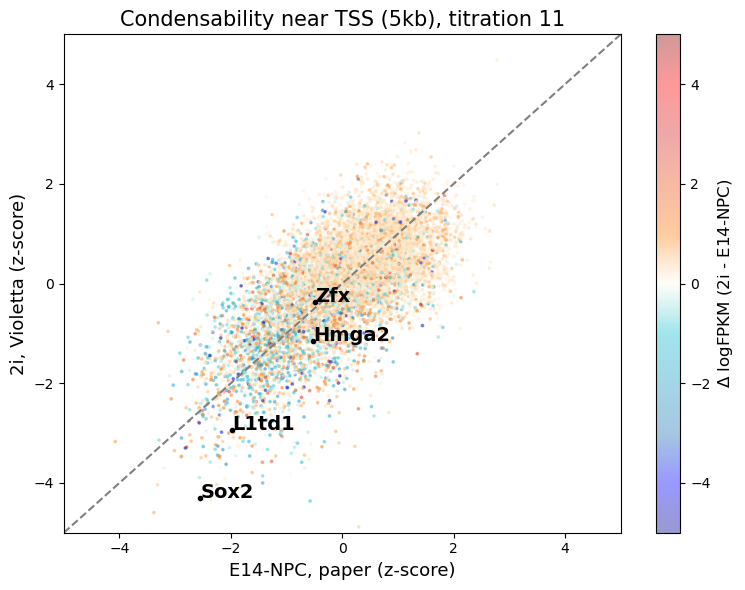

In [15]:
### Plot condensability with gene expression differences [Fig.1f]
geneID_zscorex = dkey_geneID_zscore[dkey1]
geneID_zscorey = dkey_geneID_zscore[dkey2]

zscorex_label = 'E14-NPC, paper (z-score)'
zscorey_label = '2i, Violetta (z-score)'
plot_geneIDs = sorted(set(target_geneIDs) & set(geneID_zscorex) & set(geneID_zscorey) & set(geneID_dlogFPKM))
assert plot_geneIDs, "No genes available for plotting."

lim = 5
plot_score_scatter(
    geneID_zscorex,
    geneID_zscorey,
    geneID_dlogFPKM,
    IDs=plot_geneIDs,
    standardize_color=True,
    ID_text=ESC_geneID_gname,
    fig_width=7.8,
    fig_height=6,
    vmin=-5,
    vmax=5,
    alpha=0.4,
    size=3,
    xlim=(-lim, lim),
    ylim=(-lim, lim),
    xlabel=zscorex_label,
    ylabel=zscorey_label,
    title='Condensability near TSS (5kb), titration 11',
    cbar_ylabel='$\\Delta$ logFPKM (2i - E14-NPC)',
    save_path=OUTPUT_DIR,
    save=True,
    note='E14vs2i_titr11',
)

In [16]:
### Generate a table for manual screening
import pandas as pd

common_genes = sorted(set(geneID_zscorex) & set(geneID_zscorey) & set(geneID_dlogFPKM))

df_vals = pd.DataFrame({
    'geneID': common_genes,
    zscorex_label: [geneID_zscorex[g] for g in common_genes],
    zscorey_label: [geneID_zscorey[g] for g in common_genes],
    'dlogFPKM': [geneID_dlogFPKM[g] for g in common_genes],
})

df_annot = (
    pd.DataFrame.from_dict(geneID_field_value, orient='index')
    .reset_index()
    .rename(columns={'index': 'geneID'})
)

df = df_vals.merge(df_annot, on='geneID', how='left')
df['geneName'] = df['geneName'].fillna(df['geneID'])

desired_cols = [
    'geneName',
    zscorex_label,
    zscorey_label,
    'dlogFPKM',
    'chr',
    'TSS',
    'TTS',
    'strand',
    'geneID',
    'geneType',
]
df = df[[c for c in desired_cols if c in df.columns]]

df_sorted = df.sort_values(
    by=[zscorex_label, zscorey_label, 'dlogFPKM'],
    ascending=[True, True, True],
).reset_index(drop=True)

tsv_path = OUTPUT_DIR / f"{zscorex_label}_vs_{zscorey_label}.condensabilityNearTSS.titr11.tsv"
df_sorted.to_csv(tsv_path, sep='\t', index=False)

print(tsv_path)
df_sorted.head()

/Volumes/BackupHaLab/Oct2025_run/analysis_v2/condensability_vs_TSS/E14-NPC, paper (z-score)_vs_2i, Violetta (z-score).condensabilityNearTSS.titr11.tsv


,geneName,"E14-NPC, paper (z-score)","2i, Violetta (z-score)",dlogFPKM,chr,TSS,TTS,strand,geneID,geneType
0,Gm45564,-4.075514,-3.170401,0.581030,chr7,45551614.0,45550533.0,-,ENSMUSG00000110144,antisense
1,Gm27694,-3.382995,-4.594512,0.526125,chr19,5799084.0,5798999.0,-,ENSMUSG00000098462,misc_RNA
2,Prrc2b,-3.316008,-4.035081,0.280364,chr2,32151081.0,32234536.0,+,ENSMUSG00000039262,protein_coding
3,Mir3473c,-3.301325,-0.787198,0.553085,chr1,191998633.0,191998553.0,-,ENSMUSG00000093003,miRNA
4,Ifitm5,-3.291661,-3.142183,-0.613622,chr7,140950290.0,140948957.0,-,ENSMUSG00000025489,protein_coding


In [17]:
### Generate regression-residual outlier table
# Fit y = slope * x + intercept using the same genes shown in the scatter plot.
# Report genes more than one residual standard deviation away from the fitted line.
x_values = np.asarray([geneID_zscorex[g] for g in common_genes], dtype=float)
y_values = np.asarray([geneID_zscorey[g] for g in common_genes], dtype=float)

regression = stats.linregress(x_values, y_values)
expected_y = regression.slope * x_values + regression.intercept
residuals = y_values - expected_y
residual_sd = float(np.nanstd(residuals))

if residual_sd == 0 or np.isnan(residual_sd):
    raise ValueError("Cannot compute regression-residual outliers because residual SD is zero or NaN.")

df_regression = pd.DataFrame({
    'geneID': common_genes,
    'geneName': [geneID_field_value.get(g, {}).get('geneName', g) for g in common_genes],
    zscorex_label: x_values,
    zscorey_label: y_values,
    'regression_expected_y': expected_y,
    'residual_y_minus_regression': residuals,
    'residual_zscore': residuals / residual_sd,
    'abs_residual_zscore': np.abs(residuals / residual_sd),
    'dlogFPKM': [geneID_dlogFPKM[g] for g in common_genes],
})

df_regression = df_regression.merge(df_annot, on='geneID', how='left', suffixes=('', '_gtf'))
if 'geneName_gtf' in df_regression.columns:
    df_regression['geneName'] = df_regression['geneName'].fillna(df_regression['geneName_gtf'])

regression_outlier_cols = [
    'geneName',
    zscorex_label,
    zscorey_label,
    'regression_expected_y',
    'residual_y_minus_regression',
    'residual_zscore',
    'abs_residual_zscore',
    'dlogFPKM',
    'chr',
    'TSS',
    'TTS',
    'strand',
    'geneID',
    'geneType',
]

df_regression_outliers = (
    df_regression.loc[df_regression['abs_residual_zscore'] > 1]
    .sort_values('abs_residual_zscore', ascending=False)
    .reset_index(drop=True)
)
df_regression_outliers = df_regression_outliers[[c for c in regression_outlier_cols if c in df_regression_outliers.columns]]

regression_outlier_path = OUTPUT_DIR / f"{zscorex_label}_vs_{zscorey_label}.regression_residual_gt1sd.titr11.tsv"
df_regression_outliers.to_csv(regression_outlier_path, sep='\t', index=False)

print(f"Regression line: y = {regression.slope:.4f}x + {regression.intercept:.4f}; residual SD = {residual_sd:.4f}")
print(f"Regression residual outliers (>1 SD): {len(df_regression_outliers)}")
print(regression_outlier_path)
df_regression_outliers.head()

Regression line: y = 0.6585x + -0.0026; residual SD = 0.7603
Regression residual outliers (>1 SD): 2656
/Volumes/BackupHaLab/Oct2025_run/analysis_v2/condensability_vs_TSS/E14-NPC, paper (z-score)_vs_2i, Violetta (z-score).regression_residual_gt1sd.titr11.tsv


,geneName,"E14-NPC, paper (z-score)","2i, Violetta (z-score)",regression_expected_y,residual_y_minus_regression,residual_zscore,abs_residual_zscore,dlogFPKM,chr,TSS,TTS,strand,geneID,geneType
0,Asmt,0.294260,-4.886084,0.191160,-5.077245,-6.677549,6.677549,0.238863,chrX,170672643.0,170678053.0,+,ENSMUSG00000093806,protein_coding
1,Gt(ROSA)26Sor,-0.577412,-4.363958,-0.382840,-3.981118,-5.235933,5.235933,-0.844897,chr6,113077332.0,113067427.0,-,ENSMUSG00000086429,antisense
2,Gm23582,0.225849,-3.267613,0.146111,-3.413724,-4.489701,4.489701,0.347399,chr11,21249559.0,21249421.0,-,ENSMUSG00000089155,snoRNA
3,D430013B06Rik,-0.672283,-3.701099,-0.445313,-3.255786,-4.281982,4.281982,0.104740,chr1,59648070.0,59646199.0,-,ENSMUSG00000103821,TEC
4,Add1,-0.928154,-3.810856,-0.613806,-3.197050,-4.204733,4.204733,-0.042624,chr5,34573663.0,34632307.0,+,ENSMUSG00000029106,protein_coding
